In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from lidarbathyyseg.utils import (load_pointcloud, filter_pointcloud, rotate_to_principal_axis,
                       remove_bias, chunk_pointcloud, temporary_plot)

from lidarbathyyseg.lidar_analysis import (find_best_gmm,analyze_gmm_fragments,get_universal_stable_profile,
                              filter_and_visualize_numpy_points, smooth_surface_from_points,
                              plot_surface, prepare_and_vizualize_decission_borders, save_to_las, assign_classes)
import os
import numpy as np

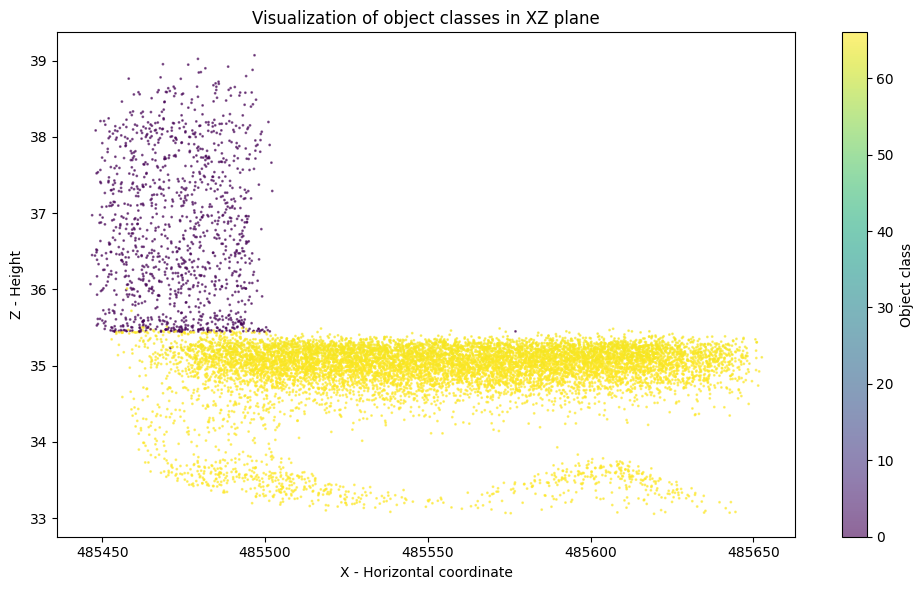

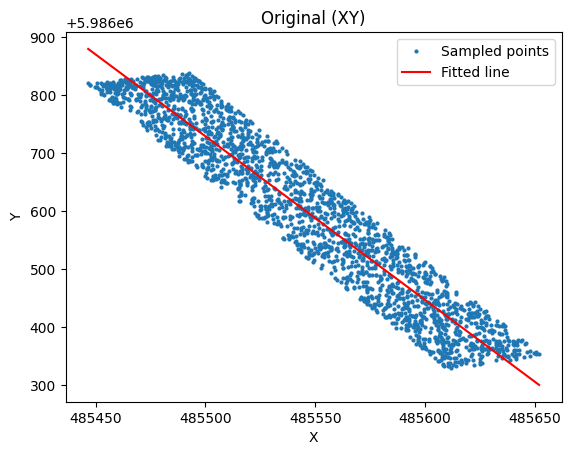

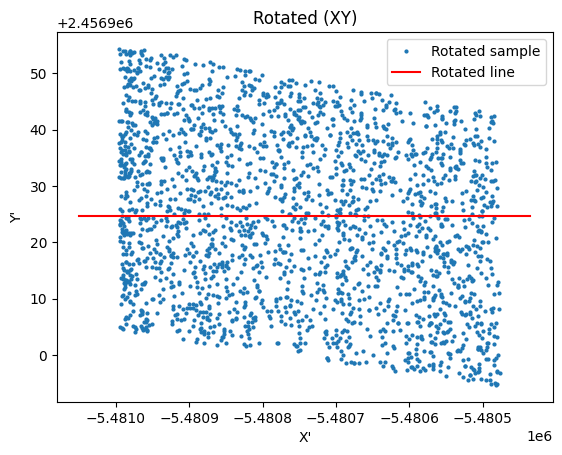

In [ ]:
path = "../data/sample/test.las"
name = os.path.basename(path).split('.')[0]
raw_pointcloud = load_pointcloud(file_path=path)
temporary_plot(raw_pointcloud)
filtered_pointcloud = filter_pointcloud(raw_pointcloud)
rotated_pointcloud, rotation_m = rotate_to_principal_axis(raw_pointcloud, plot=True)
unbiased_pointcloud = remove_bias(rotated_pointcloud)
chunks = chunk_pointcloud(unbiased_pointcloud, x_bins=10)

In [6]:
import datetime
saveplot=True

if saveplot:
    if not name:
        name = datetime.datetime.now().strftime("%m-%d-%Y==%H#%M#%S")
    else:
        tmp = datetime.datetime.now().strftime("%m-%d-%Y==%H#%M#%S")
        name = f"{name}_{tmp}"
    os.mkdir(name)


In [7]:
results = find_best_gmm(chunks, name)

In [8]:
analyze_gmm_fragments(results, path=name)

📊 Component stability (lower variance = higher stability):
  Gauss #1: Var(mean) = 0.6219, Var(std) = 0.0121
  Gauss #2: Var(mean) = 0.5941, Var(std) = 0.0484
Gauss #1 (with larger mean) is more stable.


In [9]:
stable_profile = get_universal_stable_profile(results)

In [10]:
stable_profile

{'mean': 0.8161865804382255,
 'std': 0.13106501841550378,
 'range_min': 0.4229915251917141,
 'range_max': 1.2093816356847369,
 'position': 'below',
 'dominant_component_percent': 73.33333333333333,
 'component1_count': 8,
 'component2_count': 22}

In [11]:
ids_seabed = []
ids_water = []
water_points = []
seabed_points = []
for i, chunk in enumerate(chunks):
    local_path = os.path.join(name, f"{i}")
    # print(local_path)
    remaining, removed, remaining_raw, removed_raw = filter_and_visualize_numpy_points(chunk['chunk'], stable_profile, local_path)
    ids_seabed.append(remaining_raw)
    ids_water.append(removed_raw)
    water_points.append(removed)
    seabed_points.append(remaining)
    try:
        Xg, Yg, Zg = smooth_surface_from_points(remaining)
    except Exception as e:
        print(i, remaining.shape, e)
    else:
        plot_surface(Xg, Yg, Zg, local_path)

6 (1000, 3) QH6214 qhull input error: not enough points(2) to construct initial simplex (need 4)

While executing:  | qhull d Qt Qz Qc Qbb Q12
Options selected for Qhull 2019.1.r 2019/06/21:
  run-id 500252669  delaunay  Qtriangulate  Qz-infinity-point  Qcoplanar-keep
  Qbbound-last  Q12-allow-wide  _pre-merge  _zero-centrum  Qinterior-keep
  _maxoutside  0

11 (1000, 3) QH6214 qhull input error: not enough points(1) to construct initial simplex (need 4)

While executing:  | qhull d Qt Qz Qc Qbb Q12
Options selected for Qhull 2019.1.r 2019/06/21:
  run-id 500269476  delaunay  Qtriangulate  Qz-infinity-point  Qcoplanar-keep
  Qbbound-last  Q12-allow-wide  _pre-merge  _zero-centrum  Qinterior-keep
  _maxoutside  0

22 (1000, 3) QH6214 qhull input error: not enough points(2) to construct initial simplex (need 4)

While executing:  | qhull d Qt Qz Qc Qbb Q12
Options selected for Qhull 2019.1.r 2019/06/21:
  run-id 500286283  delaunay  Qtriangulate  Qz-infinity-point  Qcoplanar-keep
  Qbbou

In [12]:
prepare_and_vizualize_decission_borders(water_points, seabed_points, name)

X - (42131, 3)
y - (42131,)
Accuracy: 0.9981013409279696
Precision: 0.9934479934479934
Recall: 1.0
F1-score: 0.9967132292522597

Full classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6001
           1       0.99      1.00      1.00      2426

    accuracy                           1.00      8427
   macro avg       1.00      1.00      1.00      8427
weighted avg       1.00      1.00      1.00      8427

Saved to: test_12-02-2025==20#49#35\SVM_decision_plane_interpolation.html


In [13]:
seabed = np.concatenate(ids_seabed)
water = np.concatenate(ids_water)
assigned_classes = assign_classes(raw_pointcloud, seabed, water)
save_to_las(assigned_classes, name)

Saved as: test_12-02-2025==20#49#35\updated_pointcloud.las
